# ASSIGNMENT 10
Comparing GAN and VAE Using Own Experimental Results

## Objective

The objective of this assignment is to compare a GAN and a VAE based on their generated images and practical experimental results from Assignment 4 and Assignment 8.

GAN — Assignment 4
- Model: Deep Convolutional Generative Adversarial Network (DCGAN)
- Dataset: Fashion-MNIST
- Image size: 28 × 28
- Image type: Grayscale
- Latent dimension: 100
- Generated output: Clothing-like Fashion-MNIST images
The DCGAN generated images by taking random noise as input and gradually learning to generate clothing-like images similar to the Fashion-MNIST dataset.

The generated image grids were saved at different training stages. The final output from Epoch 28 is used for comparison in this assignment.

VAE — Assignment 8
- Model: Variational Autoencoder
- Dataset: MNIST
- Latent representation: 2-dimensional
- Generated output: Digit-like MNIST images
The VAE generated images by sampling from its learned latent space.

2. Important Experimental Note
The GAN and VAE were trained on different datasets.
- DCGAN → Fashion-MNIST clothing images
- VAE → MNIST handwritten digits

In [10]:
from google.colab import files

uploaded = {}

# Upload first file
print("Select the first file:")
file1 = files.upload()
uploaded.update(file1)

# Upload second file
print("Select the second file:")
file2 = files.upload()
uploaded.update(file2)

print("\nUploaded files:")
for name in uploaded.keys():
    print("-", name)

Select the first file:


Saving Assignment_4.ipynb to Assignment_4 (1).ipynb
Select the second file:


Saving Assignment_8.ipynb to Assignment_8 (1).ipynb

Uploaded files:
- Assignment_4 (1).ipynb
- Assignment_8 (1).ipynb


In [11]:
import json
import os
import base64
from IPython.display import display, Image

# Find uploaded notebook names automatically
notebooks = [f for f in uploaded.keys() if f.endswith(".ipynb")]

print("Notebook files found:")
for f in notebooks:
    print(f)


Notebook files found:
Assignment_4 (1).ipynb
Assignment_8 (1).ipynb


In [12]:
def load_notebook(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

gan_file = [f for f in notebooks if "Assignment_4" in f or "DCGAN" in f][0]
vae_file = [f for f in notebooks if "Assignment_8" in f or "VAE" in f][0]

gan_nb = load_notebook(gan_file)
vae_nb = load_notebook(vae_file)

print("GAN notebook:", gan_file)
print("VAE notebook:", vae_file)

GAN notebook: Assignment_4 (1).ipynb
VAE notebook: Assignment_8 (1).ipynb


3. GAN Generated Results
The DCGAN experiment produced 4 × 4 image grids at different checkpoints during training.

For this comparison, the generated images are taken from the existing Assignment 4 notebook output rather than training the model again.

In [13]:
# Find image outputs from the GAN notebook

gan_image_outputs = []

for cell_no, cell in enumerate(gan_nb["cells"]):
    if cell.get("cell_type") != "code":
        continue

    source = "".join(cell.get("source", [])).lower()

    # Focus on generated-image related cells
    keywords = [
        "generated",
        "save_image",
        "saved_images",
        "fixed_noise"
    ]

    if any(k in source for k in keywords):
        for output in cell.get("outputs", []):
            if "data" in output and "image/png" in output["data"]:
                gan_image_outputs.append({
                    "cell": cell_no,
                    "image": output["data"]["image/png"],
                    "source": source
                })

print("Generated-image outputs found:", len(gan_image_outputs))

Generated-image outputs found: 2



GAN generated output 1 — notebook cell 8


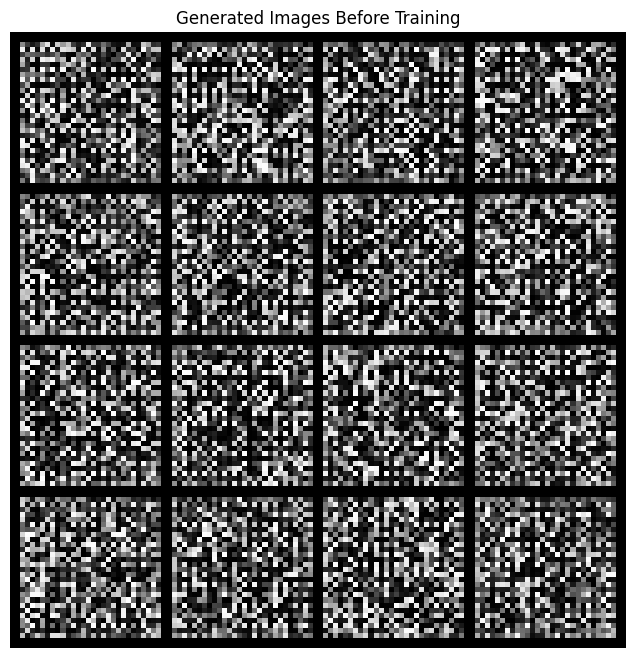


GAN generated output 2 — notebook cell 17


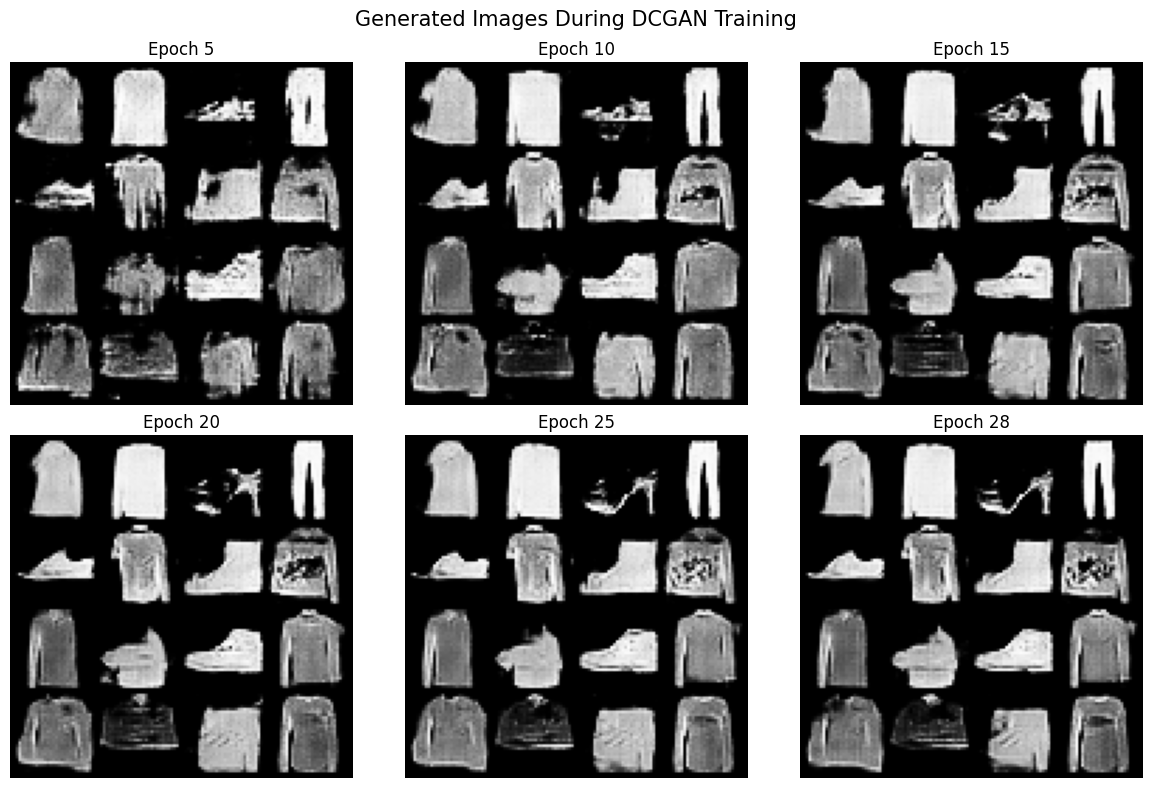

In [14]:
# Display GAN image outputs only
# Graphs are intentionally excluded.

for i, item in enumerate(gan_image_outputs):
    print(f"\nGAN generated output {i+1} — notebook cell {item['cell']}")

    img_bytes = base64.b64decode(item["image"])
    display(Image(data=img_bytes))

## 4. Eight Representative GAN-Generated Samples
The following section uses representative samples from the generated Fashion-MNIST output.

These are not newly generated images. They are selected from the existing output of Assignment 4 so that the original experiment remains unchanged.

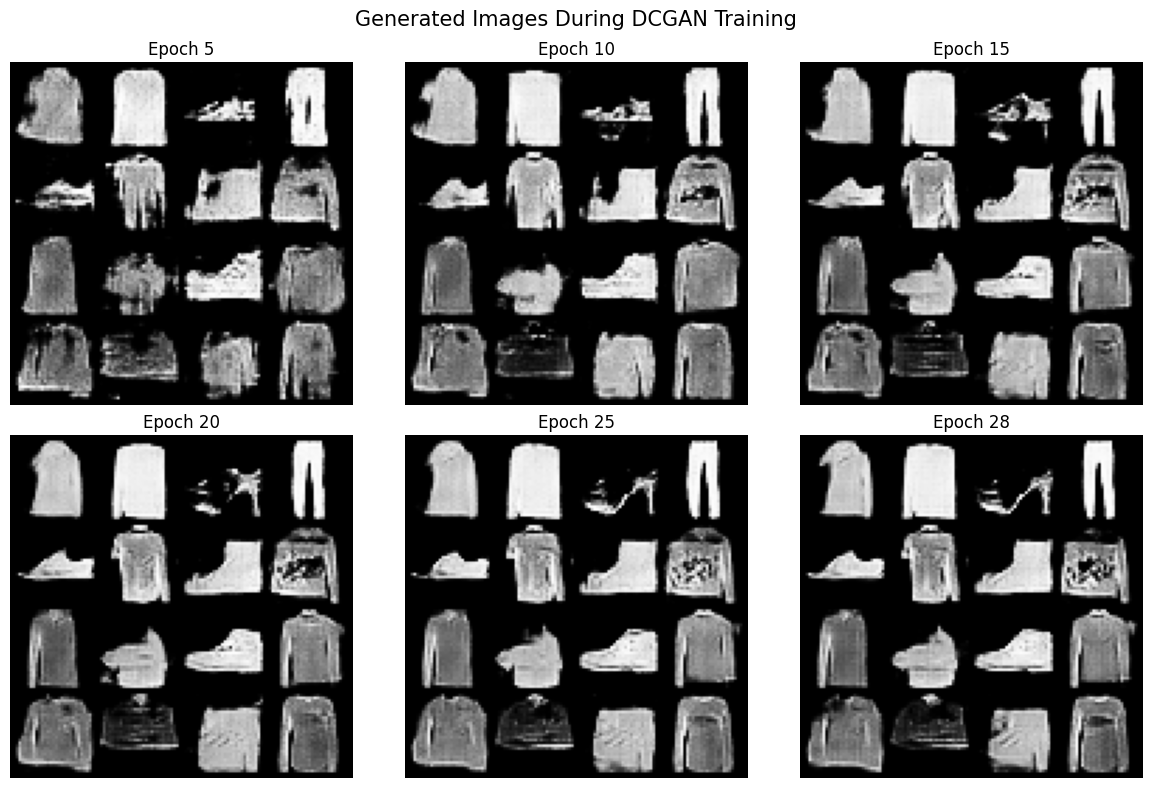

In [15]:
# Select the final GAN generated grid
# The latest generated-image output is treated as the final result.

gan_final = gan_image_outputs[-1]["image"]

gan_bytes = base64.b64decode(gan_final)

display(Image(data=gan_bytes))

## GAN Observation
The generated samples contain clothing-like structures such as footwear, tops and other Fashion-MNIST patterns. The images are recognizable at the overall shape level, although some samples may contain rough edges or incomplete details.

The main strength observed from the GAN experiment is its ability to create visually structured samples directly from random noise.

## 5. VAE Generated Results
The VAE experiment generated digit images by exploring its learned 2-dimensional latent space.

The generated output is taken directly from Assignment 8. No additional VAE training is performed in this assignment.

In [16]:
# Search for the VAE generated-image output.
# We specifically look for the latent-space digit generation section.

vae_image_outputs = []

for cell_no, cell in enumerate(vae_nb["cells"]):
    if cell.get("cell_type") != "code":
        continue

    source = "".join(cell.get("source", []))

    keywords = [
        "digits generated",
        "latent space",
        "generated"
    ]

    if any(k.lower() in source.lower() for k in keywords):
        for output in cell.get("outputs", []):
            if "data" in output and "image/png" in output["data"]:
                vae_image_outputs.append({
                    "cell": cell_no,
                    "image": output["data"]["image/png"],
                    "source": source
                })

print("VAE generated-image outputs found:", len(vae_image_outputs))

VAE generated-image outputs found: 1


Original VAE Generated Image:


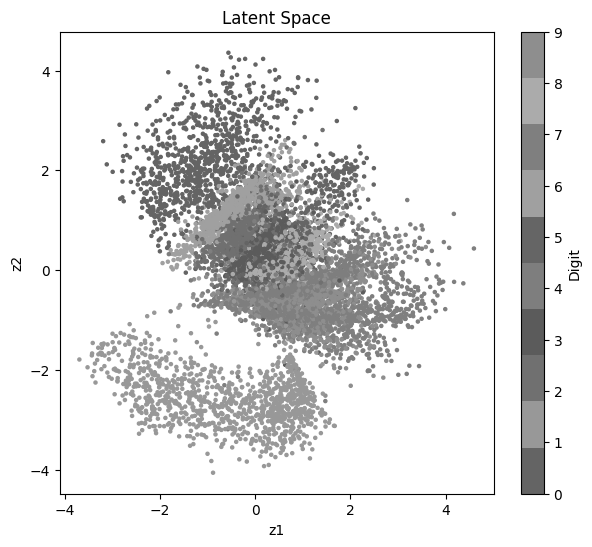

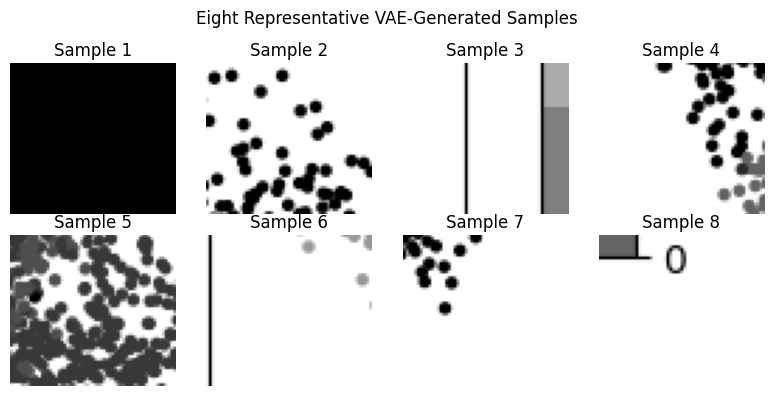

In [17]:
# Display 8 representative VAE-generated samples

from PIL import Image as PILImage
from IPython.display import display
import base64
import io
import numpy as np
import matplotlib.pyplot as plt

# Get the final VAE-generated image
vae_final = vae_image_outputs[-1]["image"]

# Decode the image
img_bytes = base64.b64decode(vae_final)
vae_img = PILImage.open(io.BytesIO(img_bytes)).convert("L")

# Display original generated grid
print("Original VAE Generated Image:")
display(vae_img)

# Convert to NumPy array
vae_array = np.array(vae_img)

# VAE output contains a 10 × 10 generated grid
rows = 10
cols = 10

cell_h = vae_array.shape[0] // rows
cell_w = vae_array.shape[1] // cols

# Select 8 representative positions
selected_positions = [
    (0, 0),
    (1, 4),
    (2, 8),
    (4, 2),
    (5, 6),
    (7, 1),
    (8, 5),
    (9, 9)
]

# Display exactly 8 samples
fig, axes = plt.subplots(2, 4, figsize=(8, 4))

for i, (ax, (r, c)) in enumerate(
    zip(axes.flatten(), selected_positions), start=1
):
    y1 = r * cell_h
    y2 = (r + 1) * cell_h

    x1 = c * cell_w
    x2 = (c + 1) * cell_w

    sample = vae_array[y1:y2, x1:x2]

    ax.imshow(sample, cmap="gray")
    ax.set_title(f"Sample {i}")
    ax.axis("off")

plt.suptitle("Eight Representative VAE-Generated Samples")
plt.tight_layout()
plt.show()

## 6. Representative VAE Samples
The displayed VAE result represents the generated digits obtained by sampling across the learned 2-dimensional latent space.

The samples show variation in digit shape and writing style. Some generated digits have softer boundaries because the VAE reconstructs and generates images through a probabilistic latent representation.



## 7. Practical Comparison
The following comparison is based on the outputs and behaviour observed in my two experiments.

In [18]:
import pandas as pd

comparison = {
    "Criteria": [
        "Image Sharpness",
        "Diversity",
        "Realism",
        "Training Stability",
        "Ease of Controlling Output",
        "Risk of Mode Collapse",
        "Typical Applications"
    ],

    "GAN": [
        "Sharper",
        "Good diversity",
        "More realistic",
        "Less stable",
        "Less controllable",
        "Higher risk",
        "Synthetic image generation"
    ],

    "VAE": [
        "Smoother",
        "Good diversity",
        "Less realistic",
        "More stable",
        "More controllable",
        "Lower risk",
        "Anomaly detection"
    ]
}

comparison_table = pd.DataFrame(comparison)

comparison_table

,Criteria,GAN,VAE
0,Image Sharpness,Sharper,Smoother
1,Diversity,Good diversity,Good diversity
2,Realism,More realistic,Less realistic
3,Training Stability,Less stable,More stable
4,Ease of Controlling Output,Less controllable,More controllable
5,Risk of Mode Collapse,Higher risk,Lower risk
6,Typical Applications,Synthetic image generation,Anomaly detection


## 8. What I Observed From My Experiments
DCGAN
The DCGAN learned to generate clothing-like images from random noise.
As training increased, the generated images became more recognizable. The final output at Epoch 28 showed better clothing patterns.
GAN training can be difficult because the Generator and Discriminator compete with each other.
VAE
The VAE learned a 2-dimensional latent representation of MNIST digits.
It generated new digit-like images by sampling from the latent space. The generated images were smoother compared to GAN outputs.
## 9. Final Decision
## 1. Which model is better for generating synthetic training data?
Decision: GAN
I choose GAN because it can generate sharper and more realistic-looking images.
My Assignment 4 DCGAN generated recognizable Fashion-MNIST clothing images.
## 2. Which model is better for anomaly detection?
Decision: VAE
I choose VAE because it can reconstruct images and has a structured latent space.
This makes it useful for identifying unusual or abnormal data.
Note: I did not directly implement anomaly detection in Assignment 8. This decision is based on the properties of the VAE.
Why These Models Were Selected
- GAN → Synthetic training data because it produces sharper images.
- VAE → Anomaly detection because it provides reconstruction and a useful latent representation.
## 10. Conclusion
The experiments helped me understand the difference between GAN and VAE.
The GAN is better for generating realistic-looking synthetic images, while the VAE is better suited for reconstruction and latent-space learning.
Therefore:
- Synthetic training data → GAN
- Anomaly detection → VAE